# Задание 2. Статистика Fortnite

Исследуем, как игровые показатели отличаются в матчах с разным итоговым местом.
Одна строка — один матч. Чем меньше `Placed`, тем лучше результат.
Построим четыре графика: две столбчатые диаграммы, boxplot и диаграмму рассеяния.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid", palette="colorblind", font="DejaVu Sans")
plt.rcParams.update({"figure.figsize": (11, 5.5)})

fortnite = pd.read_csv("datasets/Fortnite Statistics.csv")
fortnite["Accuracy"] = fortnite["Accuracy"].str.rstrip("%").astype(float)

print("Количество матчей:", len(fortnite))
print("Пропуски:", fortnite.isna().sum().sum())
print("Полные дубликаты:", fortnite.duplicated().sum())

Количество матчей: 87
Пропуски: 0
Полные дубликаты: 0


Для сравнения разделим матчи по итоговому месту: **1–10**, **11–25**, **26 и ниже**.
В группах разное число матчей, поэтому сравниваем средние значения и распределения, а не суммы.

In [2]:
groups = ["1–10 место", "11–25 место", "26 место и ниже"]
fortnite["result_group"] = pd.cut(
    fortnite["Placed"], bins=[0, 10, 25, np.inf], labels=groups
)

palette = dict(zip(groups, sns.color_palette("colorblind", 3)))
group_counts = fortnite["result_group"].value_counts().reindex(groups)
group_labels = [f"{group}\n(n = {group_counts[group]})" for group in groups]

group_counts.rename("Количество матчей").to_frame()

,Количество матчей
result_group,
1–10 место,16
11–25 место,42
26 место и ниже,29


## 1. В удачных матчах больше устранений?

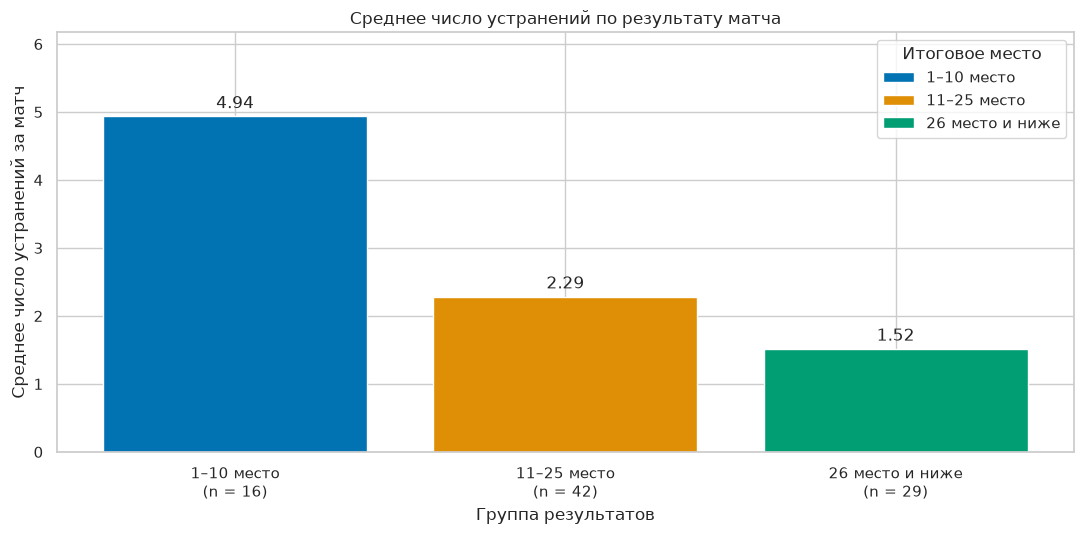

In [4]:
mean_eliminations = (
    fortnite.groupby("result_group", observed=True)["Eliminations"].mean()
)

plt.figure()
for group, label in zip(groups, group_labels):
    bars = plt.bar(label, mean_eliminations[group],
                   color=palette[group], label=group)
    plt.bar_label(bars, fmt="%.2f", padding=3)

plt.title("Среднее число устранений по результату матча")
plt.xlabel("Группа результатов")
plt.ylabel("Среднее число устранений за матч")
plt.ylim(0, mean_eliminations.max() * 1.25)
plt.legend(title="Итоговое место")
plt.tight_layout()
plt.show()

**Вывод:** сравниваем среднее число устранений в трёх группах.
В топ-10 оно равно **4,94**, на 11–25 местах — **2,29**, на 26 месте и ниже — **1,52**.
В этой выборке хорошие места сопровождаются большим числом устранений, но это не доказывает, что именно устранения стали причиной результата.

## 2. В удачных матчах выше точность?

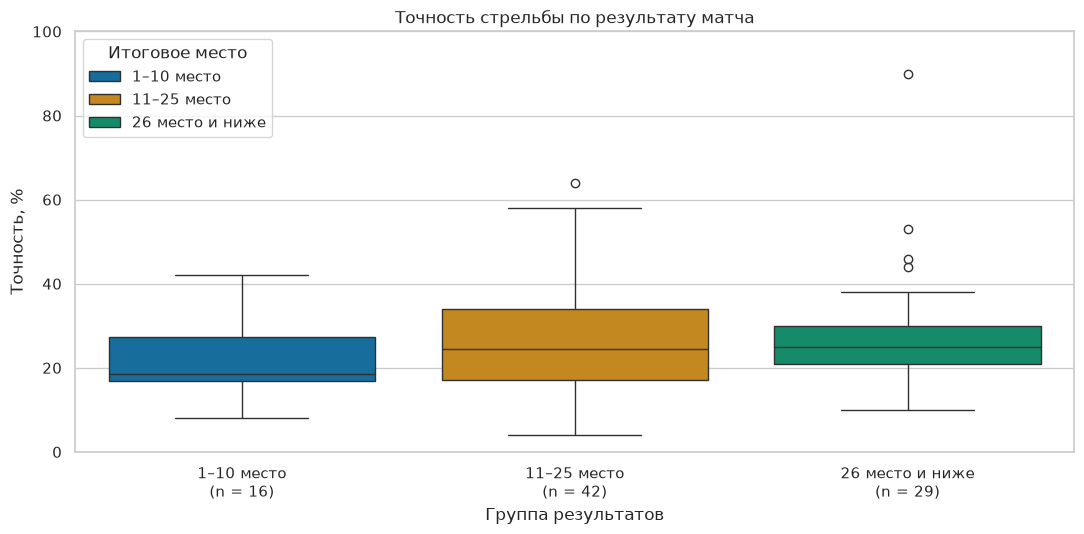

In [5]:
plt.figure()
sns.boxplot(
    data=fortnite, x="result_group", y="Accuracy",
    hue="result_group", order=groups, hue_order=groups,
    palette=palette, dodge=False, legend="full"
)
plt.xticks(range(3), group_labels)
plt.title("Точность стрельбы по результату матча")
plt.xlabel("Группа результатов")
plt.ylabel("Точность, %")
plt.ylim(0, 100)
plt.legend(title="Итоговое место")
plt.tight_layout()
plt.show()

**Вывод:** boxplot показывает распределение точности. Линия внутри коробки — медиана
(середина отсортированных значений), коробка охватывает среднюю половину результатов.
Точки за «усами» — необычные значения, не обязательно ошибки.

Медианная точность в топ-10 — **18,5%**, на 11–25 местах — **24,5%**, на 26 месте и ниже — **25%**.
В наших данных лучшие места не сопровождаются более высокой типичной точностью.
По одной точности нельзя судить об успешности матча.

## 3. Как пройденное расстояние связано с итоговым местом?

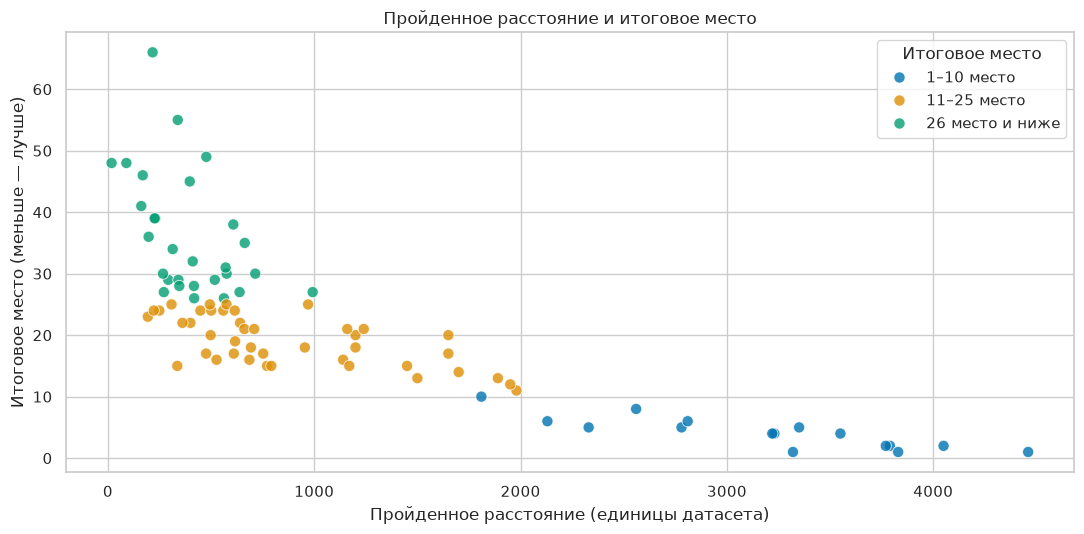

In [6]:
plt.figure()
sns.scatterplot(
    data=fortnite, x="Distance Traveled", y="Placed",
    hue="result_group", hue_order=groups, palette=palette,
    s=65, alpha=0.8
)
plt.title("Пройденное расстояние и итоговое место")
plt.xlabel("Пройденное расстояние (единицы датасета)")
plt.ylabel("Итоговое место (меньше — лучше)")
plt.legend(title="Итоговое место")
plt.tight_layout()
plt.show()

**Вывод:** каждая точка — один матч. При больших расстояниях чаще встречаются лучшие места.
Медианное расстояние в топ-10 — **3275**, на 11–25 местах — **689,42**, на 26 месте и ниже — **346,04**.
Возможное объяснение: игрок дольше остаётся в матче и успевает больше пройти.
Это не означает, что само перемещение обеспечивает хорошее место; единица расстояния в CSV не указана.

## 4. Как различаются сбор и использование материалов?

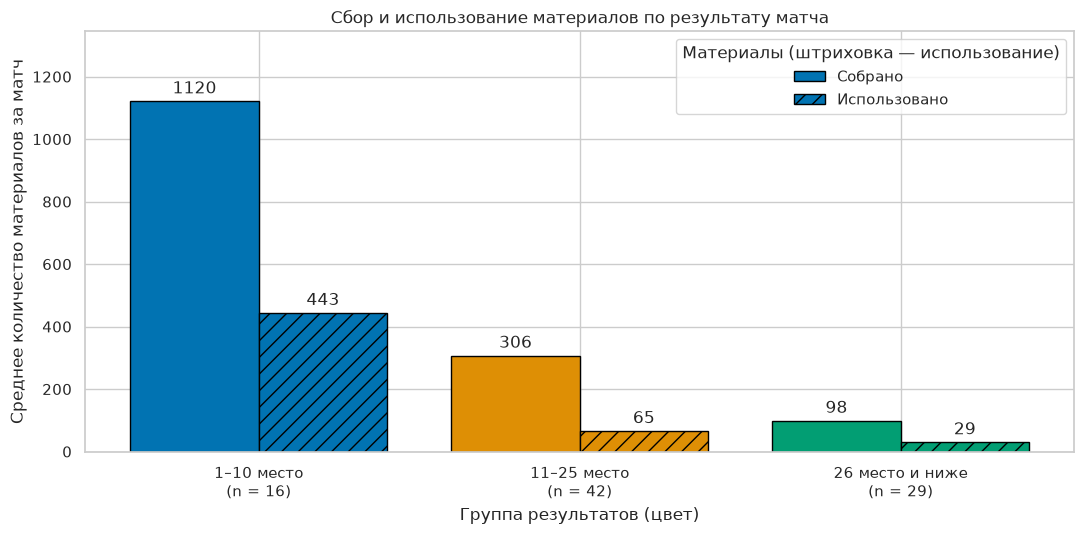

In [7]:
mean_materials = (
    fortnite.groupby("result_group", observed=True)[
        ["Materials Gathered", "Materials Used"]
    ].mean()
)

positions = np.arange(len(groups))
colors = [palette[group] for group in groups]

plt.figure()
gathered_bars = plt.bar(
    positions - 0.2, mean_materials["Materials Gathered"], width=0.4,
    color=colors, edgecolor="black", label="Собрано"
)
used_bars = plt.bar(
    positions + 0.2, mean_materials["Materials Used"], width=0.4,
    color=colors, edgecolor="black", hatch="//", label="Использовано"
)
plt.bar_label(gathered_bars, fmt="%.0f", padding=3)
plt.bar_label(used_bars, fmt="%.0f", padding=3)
plt.xticks(positions, group_labels)
plt.title("Сбор и использование материалов по результату матча")
plt.xlabel("Группа результатов (цвет)")
plt.ylabel("Среднее количество материалов за матч")
plt.ylim(0, mean_materials.to_numpy().max() * 1.2)
plt.legend(title="Материалы (штриховка — использование)")
plt.tight_layout()
plt.show()

**Вывод:** пары столбцов показывают среднее количество собранных и использованных материалов.
Цвет обозначает группу результатов, штриховка — использованные материалы.
В топ-10 в среднем собрано **1120**, использовано **443**; на 26 месте и ниже — **98** и **29**.
Во всех группах в среднем собирают больше, чем используют.
Большие значения в топ-10 могут быть связаны с более долгим участием в матче, а не только со стилем игры.

## Итог

Матчи с попаданием в топ-10 отличаются
большим средним числом устранений, большим пройденным расстоянием и количеством материалов.
При этом медианная точность в топ-10 ниже, чем в остальных группах.
Значит, одной точности недостаточно для описания успешного матча.
Выводы относятся к этим 87 записям: длительность матчей неизвестна, поэтому причины различий установить нельзя.